In [57]:
import os
import torch
import torch.nn as nn
from torchvision.datasets import Flowers102
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.utils import save_image
import pandas as pd

In [58]:

from google.colab import drive

drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/DCGAN_Flowers102-128'
os.makedirs(DRIVE_PATH, exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/output/dcgan-images", exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/output/dcgan-ckpts", exist_ok=True)

print(f"Google Drive mounted at: {DRIVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at: /content/drive/MyDrive/DCGAN_Flowers102-128


In [59]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ADD YOUR HYPERPARAMS HERE!

LATENT_DIM = 100
IMG_SHAPE = (3, 128, 128) # (c, h, w), we suggest to start with a resolution of 64x64 
BATCH_SIZE = 64
LR_G = 0.0002
LR_D = 0.0001
b1 = 0.5
b2 = 0.999
EPOCHS = 150

SAMPLE_INTERVAL =  100 # generate validation samples every N steps
CKPT_INTERVAL = 5 # save ckpt every M epochs

In [60]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(LATENT_DIM, 1024 * 4 * 4)

        self.conv = nn.Sequential(
            # 4x4 -> 8x8, 1024 -> 512
            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # 8x8 -> 16x16, 512 -> 256
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 16x16 -> 32x32, 256 -> 128
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64x64 -> 128x128, 64 -> 3
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.fc(z)
        out = out.view(out.shape[0], 1024, 4, 4)
        out = self.conv(out)
        return out

In [61]:
# DEFINE THE DISCRIMINATOR ARCHITECTURE

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            # Layer 1: 64x64 -> 32x32
            # Channels: 3 -> 64
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2: 32×32 → 16×16
            # Channels: 64 → 128
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3: 16×16 → 8×8
            # Channels: 128 → 256
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 4: 8×8 → 4×4
            # Channels: 256 → 512
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            
        )

    
        # (512, 4, 4) → 1 (real/fake)
        self.fc = nn.Linear(512 * 4 * 4, 1)

        

    def forward(self, x):
        
        out = self.conv(x)
        out = out.flatten(1) 
        out = self.fc(out)
        
        return out

In [62]:
# Loss function
criterion = nn.BCEWithLogitsLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize generator and discriminator
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [63]:
# DEFINE THE TRANSFORMS TO APPLY TO IMAGES

transform = transforms.Compose([
    transforms.Resize(128),        
    transforms.CenterCrop(128),    
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# DEFINE THE DATASET CLASSES (YOU CAN USE Flowers102 FROM torchvision.datasets)

train_set = Flowers102(
    root='./data',
    split='train',
    transform=transform,
    download=True
)
val_set = Flowers102(
    root='./data',
    split='val',
    transform=transform,
    download=True
)
test_set = Flowers102(
    root='./data',
    split='test',
    transform=transform,
    download=True
)

# CONCAT THE 3 PROVIDED SPLITS TO GET A LARGER TRAINING SET (SEE torch.utils.data.ConcatDataset)
full_set = torch.utils.data.ConcatDataset([train_set, val_set, test_set])

print("Train set: ", len(train_set))
print("Validation set: ", len(val_set))
print("Test set: ", len(test_set))
print("Full set: ", len(full_set))

if hasattr(train_set, "classes"):
    CLASSES = train_set.classes
    print("Number of classes: ", len(set(CLASSES)))

Train set:  1020
Validation set:  1020
Test set:  6149
Full set:  8189
Number of classes:  102


In [64]:
# DEFINE DATALOADERS

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size= BATCH_SIZE,
    shuffle= True,
    num_workers=2,
)
val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size= BATCH_SIZE,
    shuffle= False,
    num_workers=2,
)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size= BATCH_SIZE,
    shuffle= False,
    num_workers=2,
)

full_loader = torch.utils.data.DataLoader(
    full_set,
    batch_size= BATCH_SIZE,
    shuffle= True,
    num_workers=2,
)


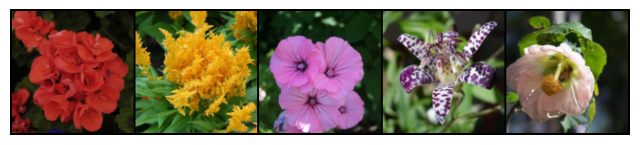

In [65]:
# get one batch
images, labels = next(iter(train_loader))

# make a grid
grid = vutils.make_grid(images[:5], nrow=5, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [66]:
def discriminator_accuracy(real_output, fake_output):
    real_output_sigmoid= torch.sigmoid(real_output)
    fake_output_sigmoid= torch.sigmoid(fake_output)

    real_predictions= (real_output_sigmoid > 0.5).float()
    fake_predictions = (fake_output_sigmoid < 0.5).float()

    real_acc = real_predictions.mean()

    fake_acc = fake_predictions.mean()

    # Overall accuracy
    total_acc = (real_acc + fake_acc) / 2
    return real_acc.item(), fake_acc.item(), total_acc.item()

In [67]:
# Optimizers
optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr= LR_G,
    betas=(b1, b2)
)
optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr= LR_D,
    betas= (b1, b2)
)


In [ ]:
# DEFINE THE TRAINING LOOP

# ----------
#  Training
# ----------


# Sample fixed noise as generator input - to visualize training progress
fixed_z = torch.randn(25, LATENT_DIM, device=device)

g_losses = []
d_losses = []
real_accuracies = []
fake_accuracies = []


for epoch in range(EPOCHS):
    for i, (real_images, _) in enumerate(full_loader):

        # ---------------------
        #  Train Discriminator
        # ---------------------

        real_images = real_images.to(device)
        batch_size = real_images.size(0)
        
        real_labels = torch.full((batch_size, 1), 0.9, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # (REMEMBER TO LOG HERE ALSO THE DISCRIMINATOR LOSS AND ACCURACIES ON REAL/FAKE)
        optimizer_D.zero_grad()
        
       
        real_output = discriminator(real_images)  # (batch_size, 1)
        d_loss_real = criterion(real_output, real_labels)


        z = torch.randn(batch_size, LATENT_DIM, device=device)
        
       
        fake_images = generator(z).detach()
        fake_output = discriminator(fake_images)  
        d_loss_fake = criterion(fake_output, fake_labels)
        
        d_loss = d_loss_real + d_loss_fake

        d_loss.backward()
        optimizer_D.step()
        
       
        real_acc, fake_acc, total_acc = discriminator_accuracy(real_output, fake_output)
        
       
        d_losses.append(d_loss.item())
        real_accuracies.append(real_acc)
        fake_accuracies.append(fake_acc)

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_G.zero_grad()
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_images = generator(z)

        fake_output = discriminator(fake_images)
        # (REMEMBER TO LOG HERE ALSO THE GENERATOR LOSS)
        g_loss = criterion(fake_output, real_labels)
        g_loss.backward()
        optimizer_G.step()

        g_losses.append(g_loss.item())

        print(
            f"[Epoch {epoch}/{EPOCHS}] [Batch {i}/{len(full_loader)}] "
            f"[D loss: {d_loss.item()}] [G loss: {g_loss.item()}] \n"
            f"Real Acc: {real_acc:.3f}  Fake Acc: {fake_acc:.3f}  Total: {total_acc:.3f}"
        )

        steps = epoch * len(full_loader) + i
        if steps % SAMPLE_INTERVAL == 0:
            # Generate a batch of images
            fake_images = generator(fixed_z)
            drive_path = f"{DRIVE_PATH}/output/dcgan-images/step-{steps}.jpg"
            
            save_image(fake_images.data[:25], drive_path, nrow=5, normalize=True)
          
         
    if ((epoch+1) % CKPT_INTERVAL) == 0:
        torch.save(generator.state_dict(), f"{DRIVE_PATH}/output/dcgan-ckpts/generator_weights_ep-{epoch+1}.pth")
        torch.save(discriminator.state_dict(), f"{DRIVE_PATH}/output/dcgan-ckpts/discriminator_weights_ep-{epoch+1}.pth")
    
        metrics_dir = f"{DRIVE_PATH}/output/dcgan-ckpts/metrics"
        os.makedirs(metrics_dir, exist_ok=True)
        metrics_df = pd.DataFrame({
            'g_loss': g_losses,
            'd_loss': d_losses,
            'real_acc': real_accuracies,
            'fake_acc': fake_accuracies
        })
        csv_save_path = f"{metrics_dir}/metrics.csv"
        metrics_df.to_csv(csv_save_path, index=False)

In [69]:
# PLOT GENERATOR AND DISCRIMINATOR LOSSES



csv_path = f"{DRIVE_PATH}/output/dcgan-ckpts/metrics/metrics.csv"
df = pd.read_csv(csv_path)
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(df['g_loss'], label='Generator Loss')
ax.plot(df['d_loss'], label='Discriminator Loss')


ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('DCGAN Losses')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/losses.jpg', dpi=150)
plt.show()

In [70]:
# PLOT REAL AND FAKE ACCURACIES


csv_path = f"{DRIVE_PATH}/output/dcgan-ckpts/metrics/metrics.csv"
df = pd.read_csv(csv_path)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['real_acc'], color='green', alpha=0.2, label='Real Acc (Raw)')
ax.plot(df['fake_acc'], color='red', alpha=0.2, label='Fake Acc (Raw)')

ax.plot(df['real_acc'].rolling(window=10).mean(), color='green', linewidth=2, label='Real Acc (Trend)')
ax.plot(df['fake_acc'].rolling(window=10).mean(), color='red', linewidth=2, label='Fake Acc (Trend)')



ax.set_xlabel('Iteration')
ax.set_ylabel('Accuracy')
ax.set_title('Discriminator Accuracies')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/accuracies.jpg', dpi=150)
plt.show()


In [ ]:
from torchvision.utils import make_grid


epochs_to_compare = [0, 10, 50, 100, 135, 150]
num_samples = 8
nrow = 8


fig, axes = plt.subplots(len(epochs_to_compare) + 1, 1, figsize=(15, 3 * (len(epochs_to_compare) + 1)))

real_batch, _ = next(iter(full_loader))
real_grid = make_grid(real_batch[:num_samples], nrow=nrow, normalize=True)
axes[0].imshow(real_grid.permute(1, 2, 0).cpu())
axes[0].set_title("Real images from dataset", fontsize=14, fontweight='bold')
axes[0].axis("off")

fixed_z_path = "/content/drive/MyDrive/DCGAN_Flowers102/output/fixed_z.pt"
if os.path.exists(fixed_z_path):

    fixed_z = torch.load(fixed_z_path, map_location=device)

    if fixed_z.dim() == 4:
        fixed_z = fixed_z.view(fixed_z.size(0), -1)
else:
    print(f"Error: Not found {fixed_z_path}")

    fixed_z = torch.randn(25, 100, device=device)

for i, ep in enumerate(epochs_to_compare):
    idx = i + 1
    path = f"{DRIVE_PATH}/output/dcgan-ckpts/generator_weights_ep-{ep}.pth"

    if os.path.exists(path):
        gen_model = Generator().to(device)
        gen_model.load_state_dict(torch.load(path, map_location=device))
        gen_model.eval()

        with torch.no_grad():
            fake_batch = gen_model(fixed_z[:num_samples])

        fake_grid = make_grid(fake_batch, nrow=nrow, normalize=True)

        axes[idx].imshow(fake_grid.permute(1, 2, 0).cpu())
        axes[idx].set_title(f"Epoch Model {ep}", fontsize=12)
        axes[idx].axis("off")
    else:
        print(f"Checkpoint not found: {path}")
        axes[idx].text(0.5, 0.5, f"Epoch {ep} not available", ha='center', va='center')
        axes[idx].axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Quality Progression: Comparison between epochs", fontsize=18)


plt.savefig(f"{DRIVE_PATH}/comparison.jpg", bbox_inches='tight', dpi=150)
plt.show()